# Cinemath ML Notebook
### Predicting Movie Buzz from Pre-Release Features

**Goal:** Given only information available *before* a movie releases (cast, genre, description, release type), 
predict how much audience engagement it will generate on Letterboxd.

**Two ML tracks:**
- **Regression** → predict `buzz_score` (log of review count, a continuous score)
- **Classification** → predict `Engagement Tier` (Low / Mid / High)

**Pipeline overview:**
1. Load & filter data → 2. Clean & engineer features → 3. TF-IDF + SVD text features → 4. Encode → 5. Train models → 6. Evaluate & compare

In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────────
import os, ast, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    r2_score, mean_squared_error,
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier
)


---
## Step 1 — Data Loading

We load three data sources and align them on `tmdb_id`:

| Source | What it contains |
|--------|-----------------|
| `movie_data_part1/2.csv` | Core movie metadata (budget, runtime, cast IDs, etc.) |
| `letterboxd_review_data` | User reviews — we count these as our engagement signal |
| `final_tmdb_movie_data` | Richer description data: overview, tagline, full cast with popularity scores |

**Filtering:** Only movies from the past 10 years with at least 50 votes are kept.  
**Sampling:** Up to 30,000 movies are randomly sampled (reproducible via `random_state=42`).

In [2]:
base = os.path.dirname(os.getcwd())

# ── 1A. LOAD MOVIES ───────────────────────────────────────────────────────
# Combine two CSV parts into one dataframe
movie_files = [
    os.path.join(base, 'final_data', 'tmdb_movie_data', 'movie_data_part1.csv'),
    os.path.join(base, 'final_data', 'tmdb_movie_data', 'movie_data_part2.csv')
]
df_movies_raw = pd.concat([pd.read_csv(f) for f in movie_files], ignore_index=True)

# Filter to movies released in the past 10 years
CURRENT_YEAR = datetime.datetime.now().year
YEAR_CUTOFF  = CURRENT_YEAR - 10

if 'release_year_x' in df_movies_raw.columns:
    df_movies_raw['_year'] = df_movies_raw['release_year_x']
elif 'release_year_y' in df_movies_raw.columns:
    df_movies_raw['_year'] = df_movies_raw['release_year_y']
else:
    df_movies_raw['_year'] = pd.to_numeric(
        df_movies_raw.get('release_date', pd.Series(dtype=str)).str[:4], errors='coerce'
    )

df_movies = df_movies_raw[df_movies_raw['_year'] >= YEAR_CUTOFF].copy()
df_movies = df_movies.drop(columns=['_year']).drop_duplicates(subset=['tmdb_id'])
print(f'Year cutoff        : {YEAR_CUTOFF}')
print(f'Movies after filter: {len(df_movies):,}')

# ── 1B. RANDOM SAMPLE ────────────────────────────────────────────────────
# Keep only movies with enough votes to be meaningful, then sample up to 30k
VOTE_THRESHOLD = 50    # movies with fewer votes are too obscure to be reliable
df_movies_sampled = (
    df_movies[df_movies['vote_count'] >= VOTE_THRESHOLD].copy()
    if 'vote_count' in df_movies.columns else df_movies.copy()
)
SAMPLE_SIZE = min(30_000, len(df_movies_sampled))
df_movies_sampled = df_movies_sampled.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
valid_tmdb_ids = set(df_movies_sampled['tmdb_id'])
print(f'After threshold    : {len(df_movies_sampled):,}  (sample of {SAMPLE_SIZE:,})')

# ── 1C. LOAD LETTERBOXD REVIEWS ──────────────────────────────────────────
# Only load reviews for movies that are in our sampled set (saves memory)
cleaned_path = os.path.join(base, 'final_data', 'letterboxd_review_data',
                            'final_data', 'letterboxd_review_data', 'cleaned_data')
review_files = sorted([os.path.join(cleaned_path, f)
                       for f in os.listdir(cleaned_path) if f.endswith('.csv')])
df_letter = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)
df_letter  = df_letter[df_letter['tmdb_id'].isin(valid_tmdb_ids)].copy()

# ── 1D. LOAD DESCRIPTION DATA ────────────────────────────────────────────
# Contains: overview, tagline, full_cast (with popularity scores)
desc_path  = os.path.join(base, 'final_data', 'final_tmdb_movie_data')
desc_files = sorted([os.path.join(desc_path, f)
                     for f in os.listdir(desc_path) if f.endswith('.csv')])
df_desc = pd.concat([pd.read_csv(f) for f in desc_files], ignore_index=True)
df_desc  = df_desc[df_desc['tmdb_id'].isin(valid_tmdb_ids)].copy()

print(f'Letterboxd shape   : {df_letter.shape}')
print(f'Desc shape         : {df_desc.shape}')

Year cutoff        : 2016
Movies after filter: 90,782
After threshold    : 9,983  (sample of 9,983)
Letterboxd shape   : (1492016, 14)
Desc shape         : (9983, 5)


---
## Step 1b — Cleaning & Feature Engineering

Here we:
1. **Drop leaky columns** — anything that requires *post-release* knowledge (ratings, revenue, box office)
2. **Engineer cast popularity features** from the full cast JSON, including the new `cast_popularity_sum`
3. **Build human-intuition features** — interpretable signals like star power tier, ensemble size, marketing completeness
4. **Derive the target variable** — `buzz_score = log(1 + num_letterboxd_reviews)`

In [3]:
# ── LETTERBOXD: engagement count only — no ratings ────────────────────────
LETTER_DROP = ['actors_url', 'director_url', 'rating', 'genre']
df_letter = df_letter.drop(columns=[c for c in LETTER_DROP if c in df_letter.columns])
df_letter = df_letter.drop_duplicates(subset=['username', 'tmdb_id'])
review_count = df_letter.groupby('tmdb_id').size().reset_index(name='num_letterboxd_reviews')

# ── MOVIES: drop ratings + identifiers ───────────────────────────────────
MOVIES_DROP = [
    'vote_average', 'vote_count', 'popularity',
    'revenue_x', 'revenue_y', 'profit_x', 'profit_y', 'profit_margin', 'budget_per_min',
    'budget_x', 'budget_y', 'runtime_y', 'original_language_y', 'in_franchise_y',
    'release_year_x', 'release_year_y', 'movie_id', 'release_date', 'director_name',
    'production_countries', 'production_country_group', 'production_companies',
    'belongs_to_collection', 'has_imdb', 'has_facebook', 'has_instagram', 'has_twitter',
    'social_media_count', 'producer_count', 'release_month', 'n_production_countries',
]
df_movies_sampled = df_movies_sampled.drop(
    columns=[c for c in MOVIES_DROP if c in df_movies_sampled.columns]
).drop_duplicates(subset=['tmdb_id'])

# ── DESCRIPTION: cast features ────────────────────────────────────────────
df_desc['overview']  = df_desc['overview'].fillna('').str.strip()
df_desc['tagline']   = df_desc['tagline'].fillna('').str.strip()
df_desc['full_cast'] = df_desc['full_cast'].fillna('[]')
df_desc['overview_word_count'] = df_desc['overview'].apply(lambda x: len(x.split()) if x else 0)
df_desc['tagline_word_count']  = df_desc['tagline'].apply(lambda x: len(x.split()) if x else 0)

# ── CAST POPULARITY FEATURES ─────────────────────────────────────────────
# The full_cast column is a JSON list of actor dicts, each with a 'popularity' score.
# We extract several features from this:
#
#   desc_cast_1/2/3_popularity  → popularity of the top 3 billed actors individually
#   desc_cast_total             → sum of top-3 only (quick proxy for star power)
#   desc_cast_max               → single biggest star score in the movie
#   cast_popularity_sum         → ★ NEW: sum of ALL actors' popularity scores
#                                  (captures full ensemble weight, not just the lead trio)

def extract_cast_pop(cast_str):
    """
    Parse the cast JSON string and return a tuple:
    (top1_pop, top2_pop, top3_pop, sum_of_all_pop)
    """
    try:
        cast = ast.literal_eval(cast_str) if isinstance(cast_str, str) else cast_str
        pops = sorted([c.get('popularity', 0) for c in cast if isinstance(c, dict)], reverse=True)
        return (
            pops[0] if len(pops) > 0 else 0,   # most popular actor
            pops[1] if len(pops) > 1 else 0,   # 2nd most popular
            pops[2] if len(pops) > 2 else 0,   # 3rd most popular
            sum(pops)                           # ★ total across ALL cast members
        )
    except:
        return 0, 0, 0, 0

cast_pops = df_desc['full_cast'].apply(extract_cast_pop)
df_desc['desc_cast_1_popularity'] = cast_pops.apply(lambda x: x[0])
df_desc['desc_cast_2_popularity'] = cast_pops.apply(lambda x: x[1])
df_desc['desc_cast_3_popularity'] = cast_pops.apply(lambda x: x[2])
df_desc['cast_popularity_sum']    = cast_pops.apply(lambda x: x[3])   # ★ NEW FEATURE

# Top-3 sum (kept for compatibility)
df_desc['desc_cast_total'] = (df_desc['desc_cast_1_popularity'] +
                               df_desc['desc_cast_2_popularity'] +
                               df_desc['desc_cast_3_popularity'])
# Single biggest star score
df_desc['desc_cast_max'] = df_desc[['desc_cast_1_popularity',
                                     'desc_cast_2_popularity',
                                     'desc_cast_3_popularity']].max(axis=1)

print("cast_popularity_sum — sample stats:")
print(df_desc['cast_popularity_sum'].describe().round(2))
df_desc = df_desc.drop_duplicates(subset=['tmdb_id'])

# ── FULL CAST: extract top-N actor names for one-hot encoding ─────────────
TOP_CAST_N = 10   # keep the top-N billed actors per movie

def extract_actor_names(cast_str, n=TOP_CAST_N):
    try:
        cast = ast.literal_eval(cast_str) if isinstance(cast_str, str) else cast_str
        # sort by 'order' (billing order) if present, else take as-is
        cast_sorted = sorted(cast, key=lambda c: c.get('order', 999))
        return [c['name'] for c in cast_sorted[:n] if 'name' in c]
    except:
        return []

df_desc['cast_names'] = df_desc['full_cast'].apply(extract_actor_names)

print('df_movies_sampled :', df_movies_sampled.shape)
print('df_desc           :', df_desc.shape)


cast_popularity_sum — sample stats:
count    9983.00
mean       18.29
std        19.13
min         0.00
25%         5.60
50%        12.13
75%        24.44
max       285.56
Name: cast_popularity_sum, dtype: float64
df_movies_sampled : (9983, 29)
df_desc           : (9983, 14)


In [4]:
# ── MERGE ALL SOURCES ───────────────────────────────────────────────────
# ── MERGE + ENGINEER HUMAN-INTUITION FEATURES ────────────────────────────
df_main = df_movies_sampled.merge(review_count, on='tmdb_id', how='left')
# NaN in num_letterboxd_reviews means the movie had no Letterboxd reviews at all.
# Filling with 0 is correct: 0 reviews = lowest possible engagement tier.
# Hyperparameter tuning (Monte Carlo) is robust to this since y_clf is already encoded.
df_main['num_letterboxd_reviews'] = df_main['num_letterboxd_reviews'].fillna(0)

# ── GENRE: most common per movie, fill missing with global mode (not Unknown) ─
cleaned_path = os.path.join(base, 'final_data', 'letterboxd_review_data',
                            'final_data', 'letterboxd_review_data', 'cleaned_data')
review_files_genre = sorted([os.path.join(cleaned_path, f)
                              for f in os.listdir(cleaned_path) if f.endswith('.csv')])
df_letter_genre = pd.concat([pd.read_csv(f) for f in review_files_genre], ignore_index=True)
df_letter_genre  = df_letter_genre[df_letter_genre['tmdb_id'].isin(valid_tmdb_ids)][['tmdb_id','genre']].dropna()
genre_mode = (
    df_letter_genre.groupby('tmdb_id')['genre']
    .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else None)
    .reset_index().rename(columns={'genre': 'primary_genre'})
)
df_main = df_main.merge(genre_mode, on='tmdb_id', how='left')
global_genre_mode = df_letter_genre['genre'].mode().iloc[0]
df_main['primary_genre'] = df_main['primary_genre'].fillna(global_genre_mode)

# ── DESCRIPTION MERGE ─────────────────────────────────────────────────────
df_main = df_main.merge(
    df_desc[['tmdb_id', 'overview', 'tagline', 'full_cast', 'cast_names',
             'overview_word_count', 'tagline_word_count',
             'desc_cast_1_popularity', 'desc_cast_2_popularity', 'desc_cast_3_popularity',
             'cast_popularity_sum', 'desc_cast_total', 'desc_cast_max']],
    on='tmdb_id', how='left'
)
for col in ['overview', 'tagline', 'full_cast']:
    df_main[col] = df_main[col].fillna('')
df_main['cast_names'] = df_main['cast_names'].apply(lambda x: x if isinstance(x, list) else [])
for col in ['overview_word_count', 'tagline_word_count', 'desc_cast_1_popularity',
            'desc_cast_2_popularity', 'desc_cast_3_popularity',
            'cast_popularity_sum', 'desc_cast_total', 'desc_cast_max']:
    df_main[col] = df_main[col].fillna(0)

# ── STRUCTURED HUMAN-INTUITION FEATURES ──────────────────────────────────
df_main['has_tagline']   = (df_main['tagline'].str.strip() != '').astype(int)
df_main['has_overview']  = (df_main['overview'].str.strip() != '').astype(int)
df_main['overview_depth'] = pd.cut(df_main['overview_word_count'],
    bins=[-1, 30, 80, float('inf')], labels=[0, 1, 2]).astype(int)
df_main['tagline_style'] = pd.cut(df_main['tagline_word_count'],
    bins=[-1, 0, 8, float('inf')], labels=[0, 1, 2]).astype(int)

def count_cast(cast_str):
    try: return len(ast.literal_eval(cast_str) if isinstance(cast_str, str) else [])
    except: return 0
df_main['cast_size']        = df_main['full_cast'].apply(count_cast)
df_main['is_ensemble_film'] = (df_main['cast_size'] >= 10).astype(int)
df_main['star_power_tier']  = pd.cut(df_main['desc_cast_max'],
    bins=[-1, 5, 20, float('inf')], labels=[0, 1, 2]).astype(int)
df_main['ensemble_richness'] = (
    (df_main['desc_cast_1_popularity'] > 5).astype(int) +
    (df_main['desc_cast_2_popularity'] > 5).astype(int) +
    (df_main['desc_cast_3_popularity'] > 5).astype(int)
)
df_main['marketing_completeness'] = (
    df_main['has_tagline'] + df_main['has_overview'] +
    (df_main['desc_cast_max'] > 0).astype(int)
)
df_main['buzz_score'] = np.log1p(df_main['num_letterboxd_reviews'])
df_main = df_main.drop(columns=['tmdb_id'], errors='ignore')

print('df_main shape  :', df_main.shape)
print('df_main columns:', df_main.columns.tolist())


df_main shape  : (9983, 51)
df_main columns: ['release_decade', 'movie_age', 'name', 'runtime_x', 'in_franchise_x', 'original_language_x', 'release_type', 'production_company_count', 'is_major_studio', 'is_us_production', 'cast_size', 'cast_1_popularity', 'cast_2_popularity', 'cast_3_popularity', 'director_popularity', 'director_prior_films', 'keywords', 'keyword_count', 'kw_independent_film', 'kw_animation', 'kw_superhero', 'kw_remake', 'kw_based_on_true_story', 'kw_sequel', 'kw_based_on_novel', 'kw_documentary', 'kw_direct-to-video', 'star_power', 'num_letterboxd_reviews', 'primary_genre', 'overview', 'tagline', 'full_cast', 'cast_names', 'overview_word_count', 'tagline_word_count', 'desc_cast_1_popularity', 'desc_cast_2_popularity', 'desc_cast_3_popularity', 'cast_popularity_sum', 'desc_cast_total', 'desc_cast_max', 'has_tagline', 'has_overview', 'overview_depth', 'tagline_style', 'is_ensemble_film', 'star_power_tier', 'ensemble_richness', 'marketing_completeness', 'buzz_score']


---
## Step 1c — TF-IDF + SVD Text Features

Movies have rich text fields (title, keywords, overview, tagline, genre). We convert these into 
numerical **theme dimensions** using TF-IDF → SVD:

- **TF-IDF** turns each movie's text into a bag-of-words vector weighted by how unique each word is
- **SVD** (Truncated) compresses 150 word dimensions down to 20 *theme* dimensions

After running the cells below, look at the **heatmap** to understand what theme each dimension 
captured (e.g. action/adventure, horror, romance), then **rename** them in the `SVD_NAMES` dict.  
Set any component to `None` to drop it from the feature set.

In [5]:
# Combines all text fields into one string per movie, then fits TF-IDF + SVD
# ── BUILD TF-IDF + SVD ───────────────────────────────────────────────────
df_main['name']     = df_main['name'].fillna('')
df_main['keywords'] = df_main['keywords'].fillna('')

df_main['_all_text'] = (
    df_main['name']             + ' ' +
    df_main['keywords']         + ' ' +
    df_main['overview']         + ' ' +
    df_main['tagline']          + ' ' +
    df_main['primary_genre']
)

tfidf = TfidfVectorizer(max_features=150, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_main['_all_text'])
vocab = np.array(tfidf.get_feature_names_out())

N_COMPONENTS = 20
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

print(f'TF-IDF matrix     : {tfidf_matrix.shape}')
print(f'After SVD         : {tfidf_reduced.shape}')
print(f'Variance explained: {svd.explained_variance_ratio_.sum():.2%}')


TF-IDF matrix     : (9983, 150)
After SVD         : (9983, 20)
Variance explained: 29.50%


In [6]:
# ── INSPECT: top words per SVD component ─────────────────────────────────
# Read this to understand what theme each dimension captured.
print(f'{"Component":<12} {"Var":>6}   Top 8 words')
print('-' * 70)
top_words_per_component = {}
for i, component in enumerate(svd.components_):
    top_idx   = component.argsort()[-8:][::-1]
    top_words = vocab[top_idx].tolist()
    top_words_per_component[i] = top_words
    print(f'SVD_{i:02d}      {svd.explained_variance_ratio_[i]:>5.2%}   {", ".join(top_words)}')


Component       Var   Top 8 words
----------------------------------------------------------------------
SVD_00      0.67%   drama, life, family, based, comedy, love, story, new
SVD_01      2.48%   story, based, true, war, drama, documentary, novel, book
SVD_02      2.08%   comedy, story, documentary, true, based, world, special, war
SVD_03      1.94%   love, romance, drama, relationship, life, woman, christmas, school
SVD_04      1.87%   documentary, life, music, film, footage, director, woman, drama
SVD_05      1.81%   christmas, family, documentary, holiday, story, romance, movie, true
SVD_06      1.69%   family, drama, war, father, son, comedy, daughter, mother
SVD_07      1.65%   war, world, action, school, animation, high, new, time
SVD_08      1.56%   school, high, family, year, old, based, girl, animation
SVD_09      1.47%   drama, war, horror, christmas, woman, school, young, director
SVD_10      1.43%   horror, love, family, war, world, romance, supernatural, house
SVD_11    

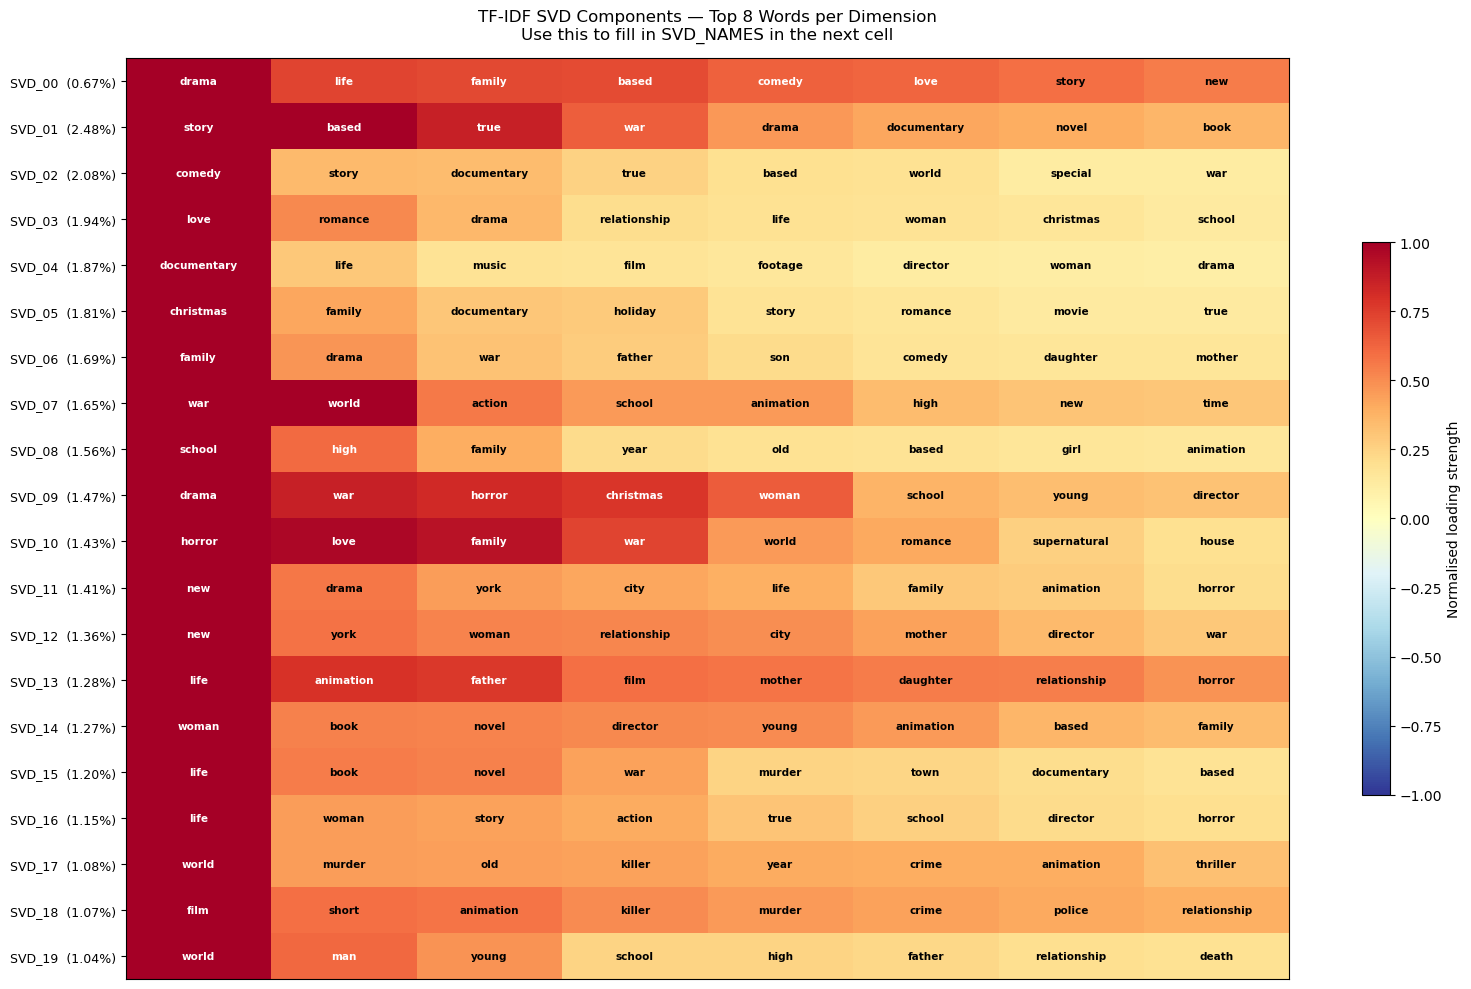

In [7]:
# ── HEATMAP: word loadings per component ─────────────────────────────────
# Darker red = strong positive loading. Use this + the print above to NAME each component.
N_WORDS = 8
loading_matrix = np.zeros((N_COMPONENTS, N_WORDS))
all_top_words  = []
for i in range(N_COMPONENTS):
    component = svd.components_[i]
    top_idx   = component.argsort()[-N_WORDS:][::-1]
    all_top_words.append(vocab[top_idx].tolist())
    loading_matrix[i] = component[top_idx]

row_max      = np.abs(loading_matrix).max(axis=1, keepdims=True)
loading_norm = loading_matrix / np.where(row_max == 0, 1, row_max)

fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(loading_norm, cmap='RdYlBu_r', aspect='auto', vmin=-1, vmax=1)
ylabels = [f'SVD_{i:02d}  ({svd.explained_variance_ratio_[i]:.2%})' for i in range(N_COMPONENTS)]
ax.set_yticks(range(N_COMPONENTS))
ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xticks([])
for col in range(N_WORDS):
    for row in range(N_COMPONENTS):
        word  = all_top_words[row][col]
        color = 'white' if abs(loading_norm[row, col]) > 0.6 else 'black'
        ax.text(col, row, word, ha='center', va='center', fontsize=7.5,
                color=color, fontweight='bold')
ax.set_title('TF-IDF SVD Components — Top 8 Words per Dimension\n'
             'Use this to fill in SVD_NAMES in the next cell', fontsize=12, pad=14)
plt.colorbar(im, ax=ax, shrink=0.6, label='Normalised loading strength')
plt.tight_layout()
plt.show()


In [8]:
# ── RENAME SVD COMPONENTS ────────────────────────────────────────────────
# After reading the heatmap + print above, update these names to match what YOU see.
# Set any component to None to DROP it from the feature set.

SVD_NAMES = {
    0:  'theme_general_context',
    1:  'theme_action_adventure',
    2:  'theme_drama_emotion',
    3:  'theme_horror_dark',
    4:  'theme_romance_family',
    5:  'theme_scifi_fantasy',
    6:  'theme_comedy_light',
    7:  'theme_crime_thriller',
    8:  'theme_language_region',
    9:  'theme_prestige_awards',
    10: 'theme_franchise_sequel',
    11: 'theme_cast_star_power',
    12: None,
    13: None,
    14: None,
    15: None,
    16: None,
    17: None,
    18: None,
    19: None,
}

named_cols = {name: tfidf_reduced[:, idx]
              for idx, name in SVD_NAMES.items() if name is not None}
tfidf_df = pd.DataFrame(named_cols, index=df_main.index)
df_main  = df_main.drop(columns=['_all_text'], errors='ignore')

print(f'SVD kept   : {len(tfidf_df.columns)} / {N_COMPONENTS}')
print(f'SVD dropped: {N_COMPONENTS - len(tfidf_df.columns)}')
print('Kept:')
for col in tfidf_df.columns:
    print(f'  theme -> {col}')


SVD kept   : 12 / 20
SVD dropped: 8
Kept:
  theme -> theme_general_context
  theme -> theme_action_adventure
  theme -> theme_drama_emotion
  theme -> theme_horror_dark
  theme -> theme_romance_family
  theme -> theme_scifi_fantasy
  theme -> theme_comedy_light
  theme -> theme_crime_thriller
  theme -> theme_language_region
  theme -> theme_prestige_awards
  theme -> theme_franchise_sequel
  theme -> theme_cast_star_power


---
## Step 1d — Encode + Build Final Feature Set

Steps:
1. **One-hot encode** categorical columns (`release_type`) — turns text categories into 0/1 columns
2. **One-hot encode** the top cast actors — each frequent actor gets their own binary column
3. **Drop text columns** that can't be fed to sklearn (raw strings)
4. **Concatenate** structured features + SVD theme features into `df_final`
5. **Leak check** — make sure no post-release info (like ratings) snuck in

In [9]:
cat_cols = ['release_type']
# original_language_x removed — testing model without any language features
# primary_genre intentionally excluded — genre is already captured in the
# named SVD theme components (theme_drama_emotion, theme_action_adventure etc.)
# One-hot encoding it causes leakage: the global-mode fill (Drama) gets
# applied to all zero-review movies, making primary_genre_Drama a proxy
# for 'this movie had no buzz' — i.e. the target itself.
cat_cols = [c for c in cat_cols if c in df_main.columns]
df_encoded = pd.get_dummies(df_main, columns=cat_cols)

# Drop primary_genre_Unknown — leakage
unknown_cols = [c for c in df_encoded.columns if 'unknown' in c.lower()]
if unknown_cols:
    df_encoded = df_encoded.drop(columns=unknown_cols)
    print(f'Dropped leakage cols: {unknown_cols}')

# ── ONE-HOT ENCODE full_cast (top actors) ────────────────────────────────
if 'cast_names' in df_main.columns:
    mlb = MultiLabelBinarizer()
    cast_ohe = pd.DataFrame(
        mlb.fit_transform(df_main['cast_names']),
        columns=[f'actor_{n.replace(" ", "_")}' for n in mlb.classes_],
        index=df_main.index
    )
    # Drop extremely rare actors (appear in < 0.1% of films) to control dimensionality
    min_appearances = max(2, int(len(df_main) * 0.001))
    cast_ohe = cast_ohe.loc[:, cast_ohe.sum() >= min_appearances]
    df_main = pd.concat([df_main, cast_ohe], axis=1)
    print(f'Cast OHE columns added: {cast_ohe.shape[1]}')

DROP_TEXT = ['name', 'keywords', '_all_text', 'overview', 'tagline',
             'full_cast', 'cast_names', 'spoken_languages', 'release_decade', 'primary_genre']
df_encoded = df_encoded.drop(columns=[c for c in DROP_TEXT if c in df_encoded.columns])

bool_cols = df_encoded.select_dtypes(include=['bool']).columns.tolist()
obj_cols  = df_encoded.select_dtypes(include=['object']).columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
for col in obj_cols:
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce').fillna(0).astype(int)

df_numeric = df_encoded.select_dtypes(include=[np.number]).fillna(0)
df_final   = pd.concat([df_numeric, tfidf_df], axis=1)

RATING_KEYWORDS = ['rating', 'log_', 'director_avg', 'genre_avg']
leaked = [c for c in df_final.columns if any(kw in c.lower() for kw in RATING_KEYWORDS)]
if leaked:
    print(f'WARNING — dropping: {leaked}')
    df_final = df_final.drop(columns=leaked)
else:
    print('OK — no rating-related columns.')

print(f'df_final shape: {df_final.shape}')
print('All features:')
for c in sorted(df_final.columns): print(f'  {c}')


Cast OHE columns added: 1227
OK — no rating-related columns.
df_final shape: (9983, 56)
All features:
  buzz_score
  cast_1_popularity
  cast_2_popularity
  cast_3_popularity
  cast_popularity_sum
  cast_size
  desc_cast_1_popularity
  desc_cast_2_popularity
  desc_cast_3_popularity
  desc_cast_max
  desc_cast_total
  director_popularity
  director_prior_films
  ensemble_richness
  has_overview
  has_tagline
  in_franchise_x
  is_ensemble_film
  is_major_studio
  is_us_production
  keyword_count
  kw_animation
  kw_based_on_novel
  kw_based_on_true_story
  kw_direct-to-video
  kw_documentary
  kw_independent_film
  kw_remake
  kw_sequel
  kw_superhero
  marketing_completeness
  movie_age
  num_letterboxd_reviews
  original_language_x
  overview_depth
  overview_word_count
  production_company_count
  release_type_streaming
  release_type_theatrical
  runtime_x
  star_power
  star_power_tier
  tagline_style
  tagline_word_count
  theme_action_adventure
  theme_cast_star_power
  theme_co

---
## Classification Track — Predicting Engagement Tier

**Target:** `Engagement Tier` — Low (0) / Mid (1) / High (2)

We split movies into 3 tiers based on review count **percentiles** (33rd and 67th). 
This gives roughly equal class sizes so the model isn't biased toward the majority class.

Using `stratify=y_clf` in the train/test split ensures the same tier distribution in both sets.

In [10]:
review_counts = df_main['num_letterboxd_reviews']
low_thresh    = review_counts.quantile(0.33)
high_thresh   = review_counts.quantile(0.67)
print(f'Thresholds:  Low <= {low_thresh:.0f}  |  Mid <= {high_thresh:.0f}  |  High > {high_thresh:.0f}')

def reviews_to_tier(n):
    if n <= low_thresh:    return 0
    elif n <= high_thresh: return 1
    else:                  return 2

y_clf = df_main['num_letterboxd_reviews'].apply(reviews_to_tier).values
print('Class distribution:')
unique, counts = np.unique(y_clf, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {["Low","Mid","High"][u]}: {c} ({c/len(y_clf):.1%})')

X_clf = df_final.drop(columns=['num_letterboxd_reviews', 'buzz_score'], errors='ignore')
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)
scaler_clf = StandardScaler()
X_clf_train_scaled = scaler_clf.fit_transform(X_clf_train)
X_clf_test_scaled  = scaler_clf.transform(X_clf_test)

print('X_clf_train:', X_clf_train.shape)
print('X_clf_test :', X_clf_test.shape)


Thresholds:  Low <= 7  |  Mid <= 73  |  High > 73
Class distribution:
  Low: 3346 (33.5%)
  Mid: 3360 (33.7%)
  High: 3277 (32.8%)
X_clf_train: (7487, 54)
X_clf_test : (2496, 54)


In [11]:
def calculate_pcc(y_true):
    """
    Calculates the Maximum Proportion Chance Criterion.
    """
    # Calculate proportions of each class
    classes = np.unique(y_true)
    proportions = [np.mean(y_true == c) for c in classes]
    
    # Maximum Proportion Chance Criterion
    pcc = np.sum([p**2 for p in proportions])
    
    # Often, a 25% improvement over PCC is recommended
    pcc_improved = pcc * 1.25
    
    return pcc, pcc_improved

pcc, pcc_improved = calculate_pcc(y_clf)
pcc_improved

0.41671619324724213

In [12]:
def evaluate_reg(name, y_train, y_train_pred, y_test, y_test_pred):
    print(f'{name}')
    print(f'  Train R2  : {r2_score(y_train, y_train_pred):.4f}')
    print(f'  Test  R2  : {r2_score(y_test,  y_test_pred):.4f}')
    print(f'  Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}\n')

def evaluate_clf(name, y_train, y_train_pred, y_test, y_test_pred):
    print(f'{name}')
    print(f'  Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}')
    print(f'  Test  Accuracy: {accuracy_score(y_test,  y_test_pred):.4f}')
    print(f'  Test  F1 Score: {f1_score(y_test, y_test_pred, average="weighted"):.4f}')
    print(f'  Test  Precision: {precision_score(y_test, y_test_pred, average="weighted", zero_division=0):.4f}')
    print(f'  Test  Recall   : {recall_score(y_test, y_test_pred, average="weighted", zero_division=0):.4f}\n')

def plot_confusion(name, y_test, y_pred, labels=None):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(cmap='Blues')
    plt.title(f'{name} -- Confusion Matrix')
    plt.tight_layout()
    plt.show()


---
## Step 2 — Random Forest + Monte Carlo Hyperparameter Tuning

Random Forest builds many decision trees on random subsets of data and features, then averages 
their predictions. It's robust to outliers and handles mixed feature types well.

**Tuning (Monte Carlo):** Instead of a fixed grid, we randomly sample hyperparameter combinations 
(`n_estimators`, `max_depth`, `min_samples_leaf`) across many trials. Each trial trains on a 
random subsample of the training data and evaluates on a held-out validation fold — this makes 
it fast even with many combinations. The best config by validation F1 is then retrained on the 
full training set.  

**NaN handling:** `num_letterboxd_reviews` can have NaN for movies with no Letterboxd presence. 
These are filled with 0 before tiering, which is correct — 0 reviews = lowest engagement. 
The hyperparameter search itself is insensitive to this since we use the already-encoded `y_clf`.


Running 40 Monte Carlo trials for Random Forest...
  Trial 01  new best F1=0.5175  params={'n_estimators': 100, 'max_depth': 3, 'min_samples_leaf': 4, 'max_features': 0.5}
  Trial 02  new best F1=0.5799  params={'n_estimators': 150, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'log2'}
  Trial 05  new best F1=0.5922  params={'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 2, 'max_features': 0.5}

Best RF params : {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 2, 'max_features': 0.5}
Best MC val F1 : 0.5922
Random Forest Classifier (Monte Carlo tuned) — Engagement Tier
  Train Accuracy: 0.7753
  Test  Accuracy: 0.6054
  Test  F1 Score: 0.6033
  Test  Precision: 0.6072
  Test  Recall   : 0.6054



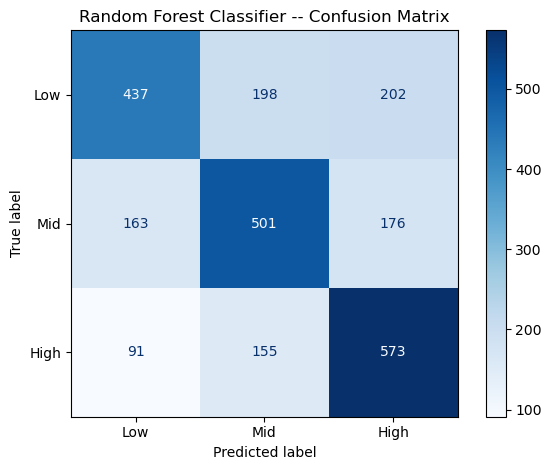

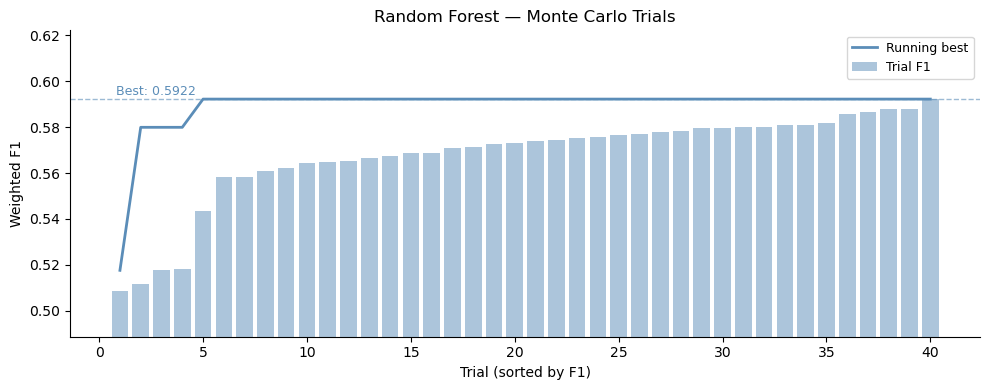

In [18]:
# ── MONTE CARLO HYPERPARAMETER TUNING — RANDOM FOREST ──────────────────
# Randomly samples hyperparameter combos instead of an exhaustive grid.
# Uses a stratified subsample for each trial to keep it fast.

N_TRIALS_RF   = 40       # number of random combinations to try
VAL_FRAC      = 0.20     # fraction of train set held out for MC validation
SUBSAMPLE_FRAC = 0.60    # fraction of train set used per trial (speed)

rng = np.random.default_rng(seed=42)

rf_param_space = {
    'n_estimators'    : [50, 100, 150, 200, 250],
    'max_depth'       : [3, 8, 10, 12, 15, None],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features'    : ['sqrt', 'log2', 0.5],
}

# Split off a small MC-validation set from training data
X_tr_mc, X_val_mc, y_tr_mc, y_val_mc = train_test_split(
    X_clf_train, y_clf_train,
    test_size=VAL_FRAC, random_state=7, stratify=y_clf_train
)

# Sub-sample indices for speed
n_sub = int(len(X_tr_mc) * SUBSAMPLE_FRAC)

best_rf_score  = -np.inf
best_rf_params = {}
rf_trial_log   = []

print(f'Running {N_TRIALS_RF} Monte Carlo trials for Random Forest...')
for trial in range(N_TRIALS_RF):
    params = {k: rng.choice(v).item() if hasattr(rng.choice(v), 'item') else rng.choice(v)
              for k, v in rf_param_space.items()}
    # Re-draw properly
    params = {k: v[rng.integers(len(v))] for k, v in rf_param_space.items()}

    # Subsample for speed
    idx = rng.choice(len(X_tr_mc), size=n_sub, replace=False)
    X_sub = X_tr_mc.iloc[idx] if hasattr(X_tr_mc, 'iloc') else X_tr_mc[idx]
    y_sub = y_tr_mc[idx]

    clf = RandomForestClassifier(
        **params, random_state=42, n_jobs=-1, class_weight='balanced'
    ).fit(X_sub, y_sub)

    val_f1 = f1_score(y_val_mc, clf.predict(X_val_mc), average='weighted')
    rf_trial_log.append({**params, 'val_f1': val_f1})

    if val_f1 > best_rf_score:
        best_rf_score  = val_f1
        best_rf_params = params
        print(f'  Trial {trial+1:02d}  new best F1={val_f1:.4f}  params={params}')

print(f'\nBest RF params : {best_rf_params}')
print(f'Best MC val F1 : {best_rf_score:.4f}')

# ── FINAL RF — retrain on full train set with best params ───────────────
rf_clf = RandomForestClassifier(
    **best_rf_params, random_state=42, n_jobs=-1, class_weight='balanced'
).fit(X_clf_train, y_clf_train)

evaluate_clf(
    f'Random Forest Classifier (Monte Carlo tuned) — Engagement Tier',
    y_clf_train, rf_clf.predict(X_clf_train),
    y_clf_test,  rf_clf.predict(X_clf_test)
)
plot_confusion('Random Forest Classifier', y_clf_test, rf_clf.predict(X_clf_test),
               labels=['Low', 'Mid', 'High'])

# ── MONTE CARLO TRIAL HISTORY — RF ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

scores       = pd.DataFrame(rf_trial_log).sort_values('val_f1')['val_f1'].values
running_best = pd.DataFrame(rf_trial_log)['val_f1'].cummax().values
trials       = np.arange(1, len(scores) + 1)

ax.bar(trials, scores, color='#5B8DB8', alpha=0.5, label='Trial F1')
ax.plot(np.arange(1, len(running_best) + 1), running_best,
        color='#5B8DB8', linewidth=2, label='Running best')
ax.axhline(scores.max(), color='#5B8DB8', linestyle='--', linewidth=1, alpha=0.6)
ax.text(len(scores) * 0.02, scores.max() + 0.002,
        f'Best: {scores.max():.4f}', fontsize=9, color='#5B8DB8')

ax.set_title('Random Forest — Monte Carlo Trials', fontsize=12)
ax.set_xlabel('Trial (sorted by F1)')
ax.set_ylabel('Weighted F1')
ax.set_ylim(scores.min() - 0.02, scores.max() + 0.03)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## Step 3 — Gradient Boosting + Monte Carlo Hyperparameter Tuning

Gradient Boosting builds trees *sequentially*, where each tree corrects the errors of the 
previous one. It tends to be more accurate than Random Forest on tabular data, but is 
also more sensitive to hyperparameters.

**Monte Carlo tuning** randomly samples `learning_rate`, `max_depth`, `subsample`, 
and `max_features` over many trials. We evaluate each combo on the same MC-validation 
fold used for RF to keep comparisons fair.


In [15]:
# ── MONTE CARLO HYPERPARAMETER TUNING — GRADIENT BOOSTING ──────────────

N_TRIALS_GB = 30    # fewer trials — GB is slower per trial

gb_param_space = {
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1, 0.15],
    'max_depth'    : [3, 4, 5, 6],
    'subsample'    : [0.6, 0.7, 0.8, 0.9],
    'max_features' : [0.5, 0.7, 0.8, 'sqrt'],
    'n_estimators' : [100, 150, 200, 250],
}

best_gb_score  = -np.inf
best_gb_params = {}
gb_trial_log   = []

print(f'Running {N_TRIALS_GB} Monte Carlo trials for Gradient Boosting...')
for trial in range(N_TRIALS_GB):
    params = {k: v[rng.integers(len(v))] for k, v in gb_param_space.items()}

    clf = GradientBoostingClassifier(
        **params, random_state=42,
        n_iter_no_change=10, validation_fraction=0.1, tol=1e-4
    ).fit(X_tr_mc, y_tr_mc)   # use same MC-train split as RF

    val_f1 = f1_score(y_val_mc, clf.predict(X_val_mc), average='weighted')
    gb_trial_log.append({**params, 'val_f1': val_f1})

    if val_f1 > best_gb_score:
        best_gb_score  = val_f1
        best_gb_params = params
        print(f'  Trial {trial+1:02d}  new best F1={val_f1:.4f}  params={params}')

print(f'\nBest GB params : {best_gb_params}')
print(f'Best MC val F1 : {best_gb_score:.4f}')

# ── FINAL GB — retrain on full train set with best params ───────────────
gb_clf = GradientBoostingClassifier(
    **best_gb_params, random_state=42
).fit(X_clf_train, y_clf_train)

evaluate_clf(
    f'Gradient Boosting Classifier (Monte Carlo tuned) — Engagement Tier',
    y_clf_train, gb_clf.predict(X_clf_train),
    y_clf_test,  gb_clf.predict(X_clf_test)
)
plot_confusion('Gradient Boosting Classifier', y_clf_test, gb_clf.predict(X_clf_test),
               labels=['Low', 'Mid', 'High'])

# ── TRIAL LOG COMPARISON ─────────────────────────────────────────────────
print('\n── Top 5 RF trials ──')
rf_log_df = pd.DataFrame(rf_trial_log).sort_values('val_f1', ascending=False)
print(rf_log_df.head())

print('\n── Top 5 GB trials ──')
gb_log_df = pd.DataFrame(gb_trial_log).sort_values('val_f1', ascending=False)
print(gb_log_df.head())

Running 30 Monte Carlo trials for Gradient Boosting...
  Trial 01  new best F1=0.6024  params={'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.7, 'max_features': 0.5, 'n_estimators': 100}


KeyboardInterrupt: 